In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
#Loading the dataset
df = pd.read_csv('/Car Market Trend Analysis.csv')

In [11]:
#review top 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
df.tail() #Last five rows.

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [17]:
#Number of columns and rows
df.shape

(301, 9)

In [49]:
#column names
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [19]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [20]:
#statistical info
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [52]:
#data quality check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows', duplicate_count)

Duplicate Rows 2


In [22]:
df = df.drop_duplicates().copy()
print('Duplicates remaining', df.duplicated().sum())

Duplicates remaining 0


In [24]:
#missing value check
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [53]:
print("Total missing values:",df.isna().sum().sum())1

Total missing values: 0


In [25]:
# Check unique values in categorical columns
categorical_columns = ['Fuel_Type', 'Seller_Type', 'Transmission']

for col in categorical_columns:
    print('\n', col)
    print(df[col].value_counts())


 Fuel_Type
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

 Seller_Type
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

 Transmission
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [26]:
# Check whether numerical columns contain invalid values
numeric_columns = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

for col in numeric_columns:
    print(col, 'negative values:', (df[col] < 0).sum())

Year negative values: 0
Selling_Price negative values: 0
Present_Price negative values: 0
Kms_Driven negative values: 0
Owner negative values: 0


In [27]:
# Car age is useful for used-car market analysis
current_year = 2026
df['Car_Age'] = current_year - df['Year']

df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [28]:
# Check the cleaned dataset
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Missing values:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Rows: 299
Columns: 10
Missing values: 0
Duplicate rows: 0


In [29]:
#Analyze
fuel_counts = df['Fuel_Type'].value_counts()
fuel_counts

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


In [30]:
seller_counts = df['Seller_Type'].value_counts()
seller_counts

,count
Seller_Type,
Dealer,193
Individual,106


In [31]:
transmission_counts = df['Transmission'].value_counts()
transmission_counts

,count
Transmission,
Manual,260
Automatic,39


In [32]:
car_counts = df['Car_Name'].value_counts()
car_counts.head(10)

,count
Car_Name,
city,26
corolla altis,16
verna,14
brio,10
fortuner,10
ciaz,9
i20,9
innova,9
grand i10,8


In [34]:
average_price = df['Selling_Price'].mean()
median_price = df['Selling_Price'].median()

print(f'Average selling price: {average_price:.2f} lakhs')
print(f'Median selling price: {median_price:.2f} lakhs')

Average selling price: 4.59 lakhs
Median selling price: 3.51 lakhs


In [35]:
average_price_by_fuel = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
average_price_by_fuel

,Selling_Price
Fuel_Type,
Diesel,10.102759
Petrol,3.264184
CNG,3.100000


In [36]:
average_price_by_transmission = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
average_price_by_transmission

,Selling_Price
Transmission,
Automatic,9.071795
Manual,3.917308


In [37]:
brand_summary = df.groupby('Car_Name').agg(
    Number_of_Cars=('Car_Name', 'count'),
    Average_Selling_Price=('Selling_Price', 'mean'),
    Average_Present_Price=('Present_Price', 'mean'),
    Average_Kms_Driven=('Kms_Driven', 'mean')
).sort_values('Number_of_Cars', ascending=False)

brand_summary.head(10)

,Number_of_Cars,Average_Selling_Price,Average_Present_Price,Average_Kms_Driven
Car_Name,,,,
city,26,7.419231,11.791923,39296.923077
corolla altis,16,7.183125,17.582500,54293.875000
verna,14,6.107857,9.400000,42747.285714
brio,10,4.745000,6.044000,24735.800000
fortuner,10,18.254000,30.745000,64973.100000
innova,9,12.777778,17.846667,58713.111111
i20,9,4.766667,7.205556,34867.000000
ciaz,9,7.472222,9.756667,27926.222222
grand i10,8,4.943750,5.700000,23737.375000


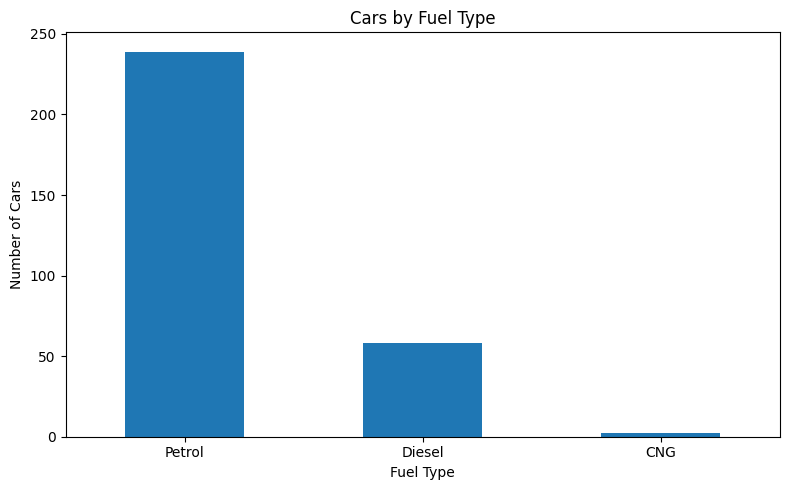

In [38]:
# Chart 1: Cars by fuel type
plt.figure(figsize=(8, 5))
fuel_counts.plot(kind='bar')
plt.title('Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

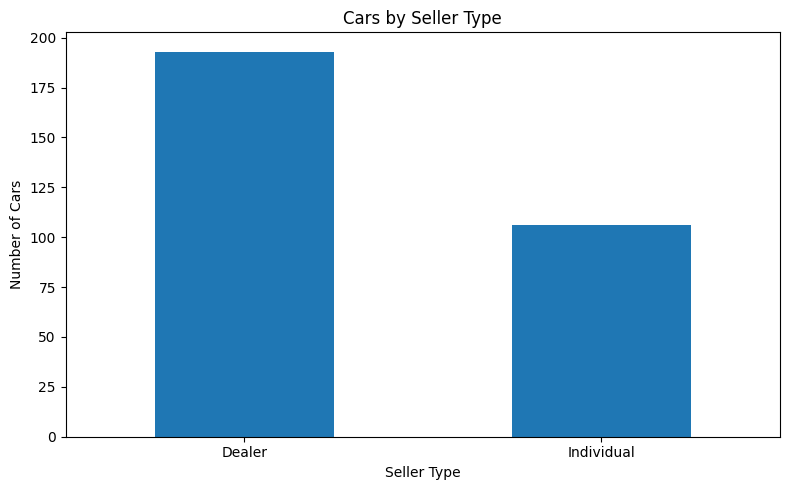

In [39]:
# Chart 2: Cars by seller type
plt.figure(figsize=(8, 5))
seller_counts.plot(kind='bar')
plt.title('Cars by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

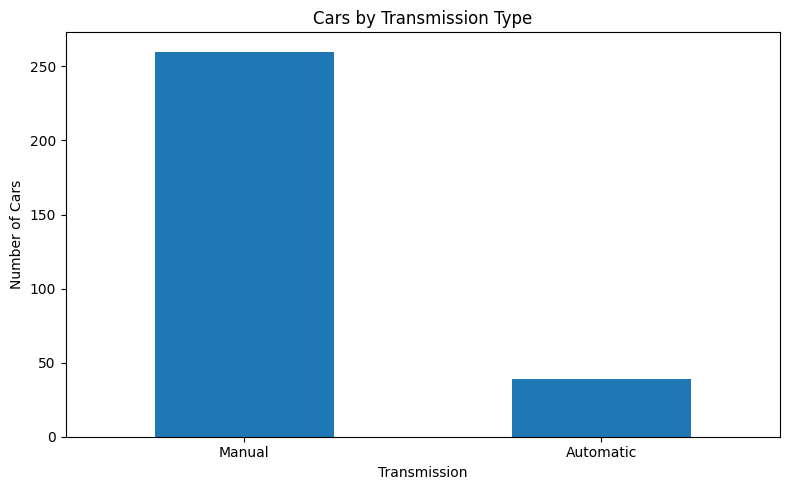

In [40]:
# Chart 3: Cars by transmission
plt.figure(figsize=(8, 5))
transmission_counts.plot(kind='bar')
plt.title('Cars by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Number of Cars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

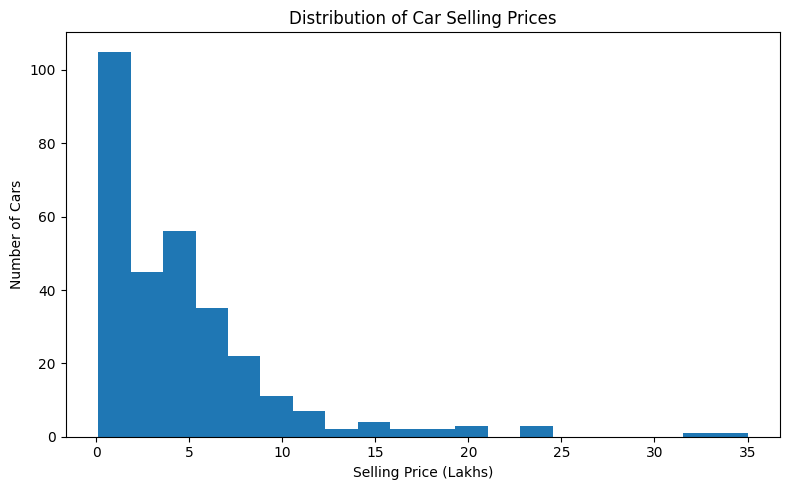

In [41]:
# Chart 4: Selling price distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Selling_Price'], bins=20)
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price (Lakhs)')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()

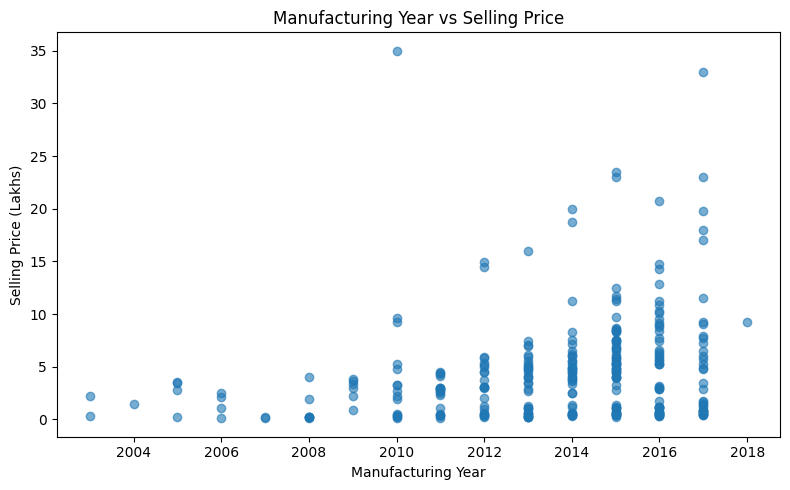

In [42]:
# Chart 5: Manufacturing year vs selling price
plt.figure(figsize=(8, 5))
plt.scatter(df['Year'], df['Selling_Price'], alpha=0.6)
plt.title('Manufacturing Year vs Selling Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

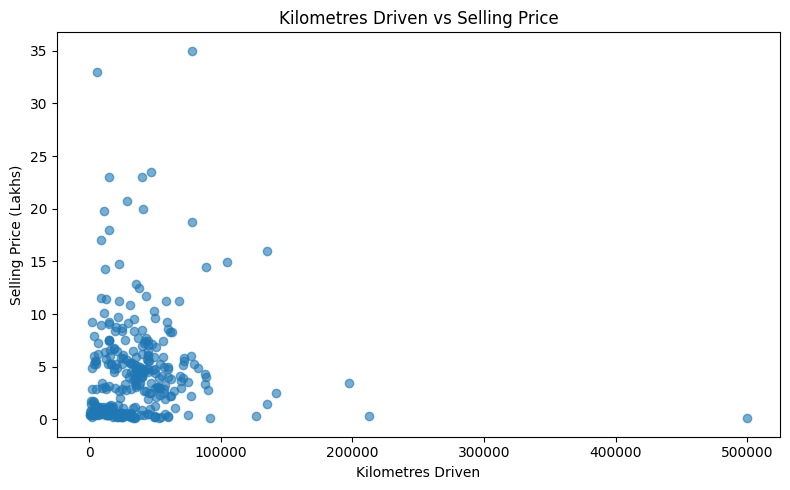

In [43]:
# Chart 6: Kilometres driven vs selling price
plt.figure(figsize=(8, 5))
plt.scatter(df['Kms_Driven'], df['Selling_Price'], alpha=0.6)
plt.title('Kilometres Driven vs Selling Price')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

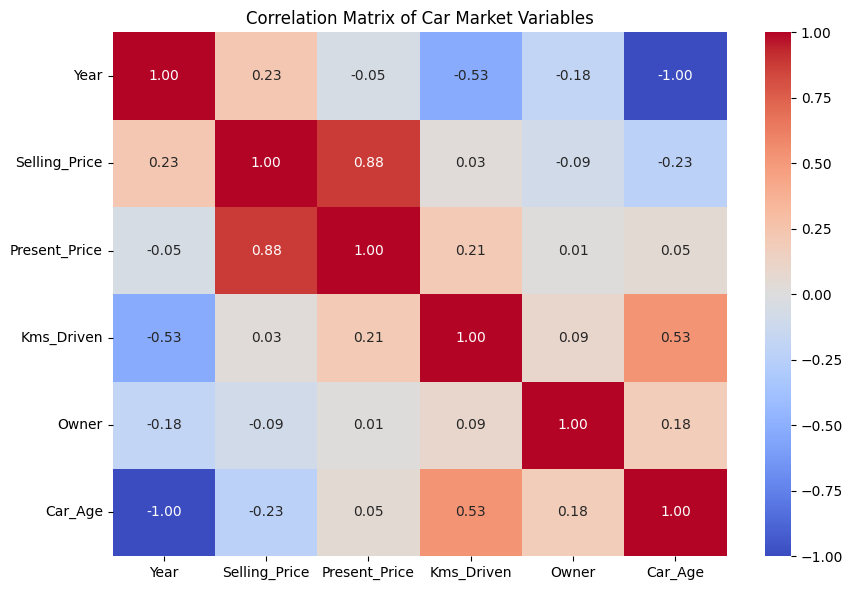

In [44]:
# Chart 7: Correlation heatmap
correlation = df[['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Car Market Variables')
plt.tight_layout()
plt.show()

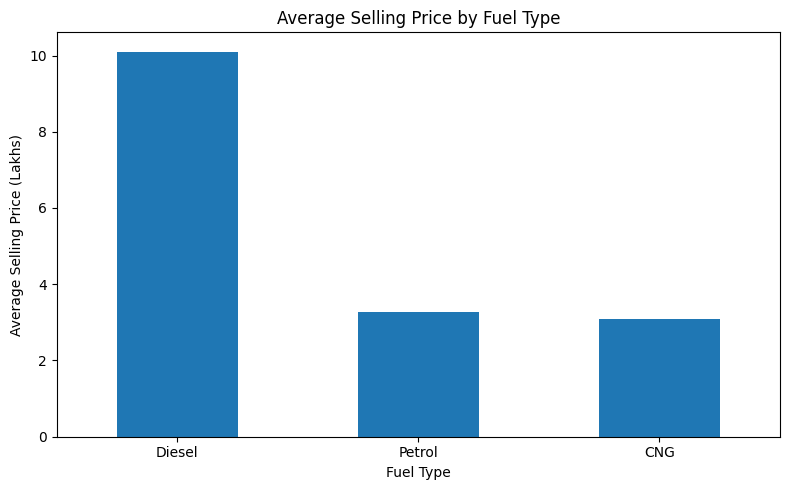

In [45]:
# Chart 8: Average selling price by fuel type
plt.figure(figsize=(8, 5))
average_price_by_fuel.plot(kind='bar')
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (Lakhs)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# Final market insights
print('Total cars analysed:', len(df))
print('Most common fuel type:', df['Fuel_Type'].mode()[0])
print('Most common seller type:', df['Seller_Type'].mode()[0])
print('Most common transmission:', df['Transmission'].mode()[0])
print('Most common car model:', df['Car_Name'].mode()[0])
print('Average selling price:', round(df['Selling_Price'].mean(), 2), 'lakhs')
print('Average present price:', round(df['Present_Price'].mean(), 2), 'lakhs')
print('Average kilometres driven:', round(df['Kms_Driven'].mean(), 2))

Total cars analysed: 299
Most common fuel type: Petrol
Most common seller type: Dealer
Most common transmission: Manual
Most common car model: city
Average selling price: 4.59 lakhs
Average present price: 7.54 lakhs
Average kilometres driven: 36916.75
